# 04 — Feature: ScreenResolution
Parses the `ScreenResolution` string into structured numeric features.

**Output features:** `Screen_Width`, `Screen_Height`, `Screen_PPI`, `Screen_IsTouchscreen`, `Screen_IsIPS`, `Screen_IsRetina`, `Screen_IsFullHD`, `Screen_Is4K`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")

Shape: (1303, 16)


In [3]:
# Explore ScreenResolution
print(ld['ScreenResolution'].value_counts().head(20))
print(f"\nUnique values: {ld['ScreenResolution'].nunique()}")

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [4]:
# Extract width and height from resolution string (e.g., "1920x1080")
def extract_resolution(s):
    match = re.search(r'(\d{3,4})x(\d{3,4})', str(s))
    if match:
        return int(match.group(1)), int(match.group(2))
    return np.nan, np.nan

ld[['Screen_Width', 'Screen_Height']] = ld['ScreenResolution'].apply(
    lambda s: pd.Series(extract_resolution(s))
)
print("Sample:")
print(ld[['ScreenResolution', 'Screen_Width', 'Screen_Height']].head(5).to_string())
print(f"\nNull widths: {ld['Screen_Width'].isnull().sum()}")

Sample:
                     ScreenResolution  Screen_Width  Screen_Height
0  IPS Panel Retina Display 2560x1600          2560           1600
1                            1440x900          1440            900
2                   Full HD 1920x1080          1920           1080
3  IPS Panel Retina Display 2880x1800          2880           1800
4  IPS Panel Retina Display 2560x1600          2560           1600

Null widths: 0


In [5]:
# PPI = sqrt(W^2 + H^2) / diagonal_inches
# 'Inches' column is already numeric in the CSV
ld['Screen_PPI'] = (
    np.sqrt(ld['Screen_Width']**2 + ld['Screen_Height']**2) / ld['Inches']
).round(2)
print("PPI stats:")
print(ld['Screen_PPI'].describe())

PPI stats:
count    1303.000000
mean      146.634589
std        43.121346
min        90.580000
25%       127.340000
50%       141.210000
75%       157.350000
max       352.470000
Name: Screen_PPI, dtype: float64


In [6]:
# Boolean flags parsed from text
ld['Screen_IsTouchscreen'] = ld['ScreenResolution'].str.contains('Touchscreen', case=False, na=False).astype(int)
ld['Screen_IsIPS']         = ld['ScreenResolution'].str.contains('IPS', case=False, na=False).astype(int)
ld['Screen_IsRetina']      = ld['ScreenResolution'].str.contains('Retina', case=False, na=False).astype(int)
ld['Screen_IsFullHD']      = ((ld['Screen_Width'] == 1920) & (ld['Screen_Height'] == 1080)).astype(int)
ld['Screen_Is4K']          = (ld['Screen_Width'] >= 3840).astype(int)

print("Flag counts:")
flag_cols = ['Screen_IsTouchscreen', 'Screen_IsIPS', 'Screen_IsRetina', 'Screen_IsFullHD', 'Screen_Is4K']
print(ld[flag_cols].sum())

Flag counts:
Screen_IsTouchscreen    192
Screen_IsIPS            365
Screen_IsRetina          17
Screen_IsFullHD         841
Screen_Is4K              43
dtype: int64


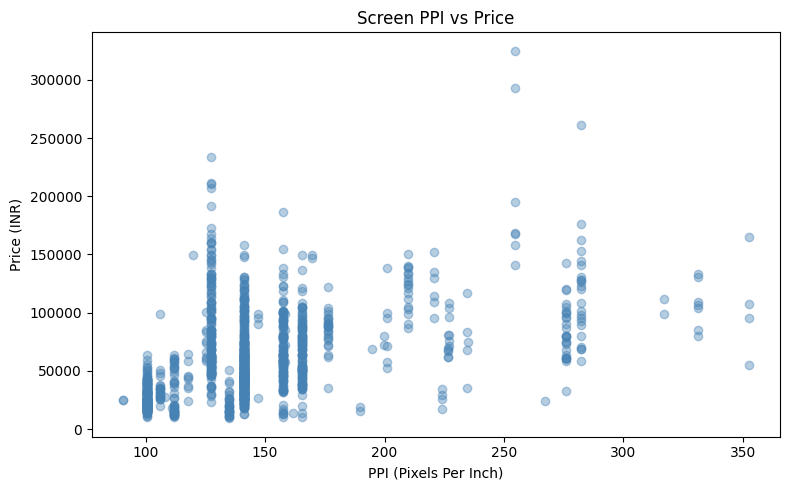

In [7]:
# Visualize PPI vs Price
plt.figure(figsize=(8, 5))
plt.scatter(ld['Screen_PPI'], ld['Price'], alpha=0.4, color='steelblue')
plt.title("Screen PPI vs Price")
plt.xlabel("PPI (Pixels Per Inch)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

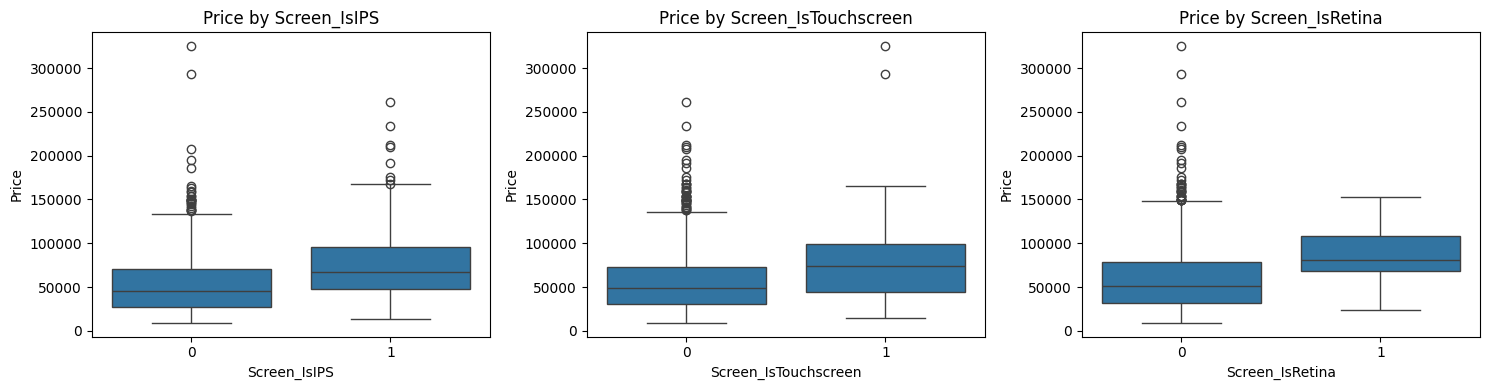

In [8]:
# Visualize resolution flags vs Price
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Screen_IsIPS', 'Screen_IsTouchscreen', 'Screen_IsRetina']):
    sns.boxplot(data=ld, x=col, y='Price', ax=ax)
    ax.set_title(f"Price by {col}")
plt.tight_layout()
plt.show()

In [9]:
# Correlation with Price
screen_cols = ['Screen_Width', 'Screen_Height', 'Screen_PPI',
               'Screen_IsTouchscreen', 'Screen_IsIPS', 'Screen_IsRetina',
               'Screen_IsFullHD', 'Screen_Is4K']
print("Correlation with Price:")
print(ld[screen_cols + ['Price']].corr()['Price'].sort_values(ascending=False))

Correlation with Price:
Price                   1.000000
Screen_Width            0.556529
Screen_Height           0.552809
Screen_PPI              0.473506
Screen_Is4K             0.343982
Screen_IsIPS            0.252208
Screen_IsFullHD         0.192937
Screen_IsTouchscreen    0.191226
Screen_IsRetina         0.087895
Name: Price, dtype: float64


In [10]:
# Drop raw column
ld.drop(columns=['ScreenResolution'], inplace=True)

In [11]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print(f"Columns: {list(ld.columns)}")

Saved: laptop_data_features.csv
Shape: (1303, 23)
Columns: ['Inches', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Company_TE', 'Type_2 in 1 Convertible', 'Type_Gaming', 'Type_Netbook', 'Type_Notebook', 'Type_Ultrabook', 'Type_Workstation', 'Screen_Width', 'Screen_Height', 'Screen_PPI', 'Screen_IsTouchscreen', 'Screen_IsIPS', 'Screen_IsRetina', 'Screen_IsFullHD', 'Screen_Is4K']
